# Executive Summary

This project analyzes vendor-related expenses for the year 2025 to evaluate spending patterns, vendor concentration, seasonal trends, and data quality risks.

## Key Objectives
- Identify vendors with the highest financial exposure
- Analyze monthly expense trends
- Detect abnormal transactions
- Propose data quality control mechanisms

## Key Findings

1. **Vendor Concentration Risk**  
   A small number of vendors account for a significant portion of total expenses, with one vendor consistently dominating across multiple months. This indicates financial dependency and potential negotiation risk.

2. **Seasonal Spending Fluctuation**  
   Monthly expenses fluctuate throughout 2025, with a notable spike in October and lower activity in March. This suggests possible seasonal or operational cycle effects.

3. **Anomaly Detection & Data Quality Control**  
   Using the IQR statistical method, one transaction (945,000 AED) was flagged as an outlier. The value appears inconsistent with surrounding transaction patterns and may represent a data-entry error (e.g., incorrect decimal placement).  

   An automated outlier flagging rule was implemented to ensure transactions exceeding the statistical upper boundary are reviewed before financial reporting.

## Conclusion

This analysis demonstrates the use of Python and Pandas for financial data analysis, trend identification, vendor exposure assessment, and automated anomaly detection.  

The framework developed in this project can be extended to support financial monitoring and internal control processes.

# Vendor Expense Analysis — 2025

## Objective
Analyze vendor-related expenses for 2025 to:
- Identify dominant vendors
- Detect seasonal spending trends
- Detect abnormal transactions
- Propose data quality controls

## Data Loading
Load cleaned dataset for analysis.

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from google.colab import drive
drive.mount('/content/drive')





Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [64]:
file_path = '/content/drive/MyDrive/Colab Notebooks/Daily_practice/1.Mini_projects/vendor_expense_analysis_2025/data/Purshasing_list.csv'
df = pd.read_csv(file_path)
df.head()

,Payment Picture Number,Date,Company,Amount,Warehouse,Tax Invoice Received,Transaction Type
0,4,01/01/2025,ADNOC,97,Warehouse Farm Houses,Tax Invoice Received #20250101124617513540 fro...,Receipt from Vendor
1,4,01/01/2025,AL SAFEER CONTRACTING,500,Warehouse Farm Houses,Not Required,Receipt from Vendor
2,4,01/04/2025,BLUE OASIS BUILDING MATERIALS,100.04,Warehouse Farm Houses,"Tax Invoice Received #B119619 from January 4, ...",Receipt from Vendor
3,4,01/04/2025,AHLAN ELECTRICAL EQUIPMENT 1 EST,939.23,Warehouse Farm Houses,"Tax Invoice Received #A-8924 from January 4, 2025",Receipt from Vendor
4,4,01/04/2025,ROYAL DIESEL SERVICES,85.02,Warehouse Farm Houses,"Tax Invoice Received #399395 from April 4, 2025",Receipt from Vendor


## Monthly Expense Trend (2025)
Analyzing total vendor expenses month by month.

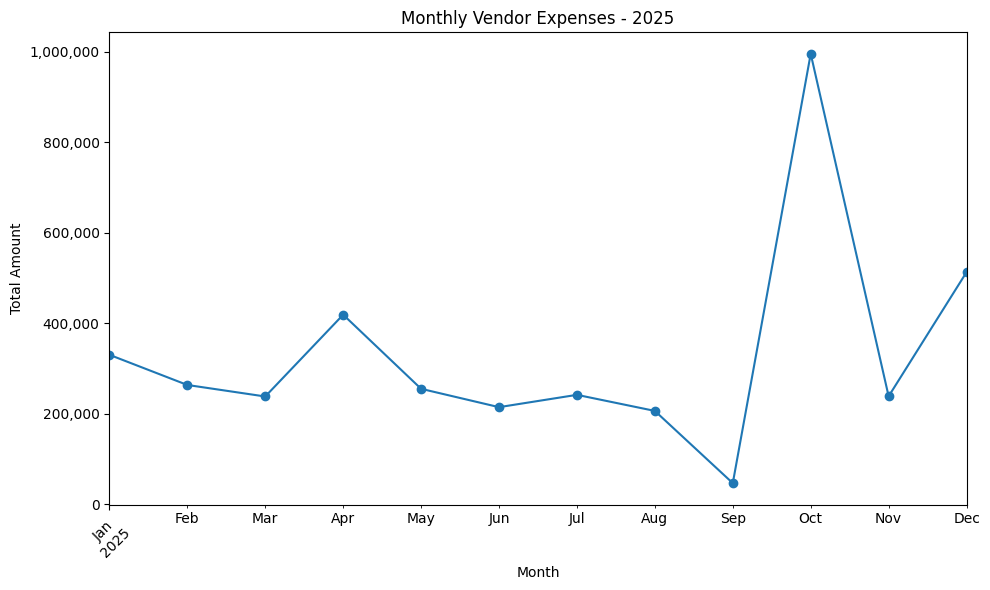

In [65]:
df["Date"] = pd.to_datetime(df["Date"])

# Convert 'Amount' to numeric, handling commas and coercing errors
df["Amount"] = df["Amount"].astype(str).str.replace(',', '', regex=False)
df["Amount"] = pd.to_numeric(df["Amount"], errors='coerce')

# Filter data for the year 2025
df_2025 = df[df["Date"].dt.year == 2025].copy()

df_2025["Month"] = df_2025["Date"].dt.to_period("M")

monthly_totals = df_2025.groupby("Month")["Amount"].sum()

ax = monthly_totals.plot(figsize=(10,6), marker="o")
ax.set_title("Monthly Vendor Expenses - 2025")
ax.set_xlabel("Month")
ax.set_ylabel("Total Amount")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top Vendors by Total Expense

Identifying vendors with highest financial exposure in 2025.

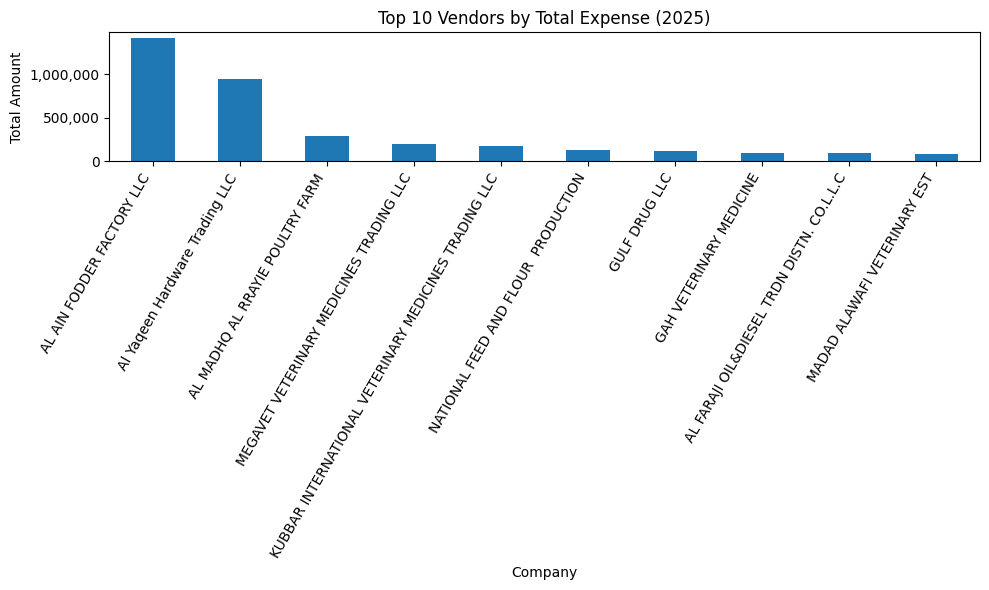

In [66]:
company_totals = df.groupby("Company")["Amount"].sum().sort_values(ascending=False)

ax = company_totals.head(10).plot(kind="bar", figsize=(10,6))

ax.set_title("Top 10 Vendors by Total Expense (2025)")
ax.set_xlabel("Company")
ax.set_ylabel("Total Amount")

ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f}'))

plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

## Outlier Detection & Data Quality Control

Using statistical methods (IQR) to detect abnormal transactions that may indicate data-entry errors or unusual financial events.

In [67]:
# IQR Method
Q1 = df["Amount"].quantile(0.25)
Q3 = df["Amount"].quantile(0.75)
IQR = Q3 - Q1

upper_limit = Q3 + 1.5 * IQR

# Create flag
df["Outlier_Flag"] = df["Amount"] > upper_limit

# View suspicious transactions
outliers = df[df["Outlier_Flag"] == True]

outliers.sort_values(by="Amount", ascending=False)

,Payment Picture Number,Date,Company,Amount,Warehouse,Tax Invoice Received,Transaction Type,Outlier_Flag
737,3,2025-10-21,Al Yaqeen Hardware Trading LLC,945000.00,Warehouse Farm Houses,"Tax Invoice Received #39473 from October 21, 2025",Receipt from Vendor,True
831,3,2025-12-17,AL MADHQ AL RRAYIE POULTRY FARM,98476.56,Warehouse Farm Houses,"Tax Invoice Received #1102 from December 17, 2025",Receipt from Vendor,True
861,3,2025-12-31,AL MADHQ AL RRAYIE POULTRY FARM,98476.56,Warehouse Farm Houses,"Tax Invoice Received #1138 from December 31, 2025",Receipt from Vendor,True
847,3,2025-12-24,AL MADHQ AL RRAYIE POULTRY FARM,98476.56,Warehouse Farm Houses,"Tax Invoice Received #1118 from December 24, 2025",Receipt from Vendor,True
416,3,2025-05-30,MEGAVET VETERINARY MEDICINES TRADING LLC,71062.04,Warehouse-hatchery (materials),"Tax Invoice Received #10A06257 from May 30, 2025",Receipt from Vendor,True
...,...,...,...,...,...,...,...,...
798,3,2025-12-05,MADAD ALAWAFI VETERINARY EST,2976.75,Warehouse Farm Houses,Tax Invoice Received #INV/2025/12/0010 from De...,Receipt from Vendor,True
407,3,2025-05-29,AHLAN ELECTRICAL EQUIPMENT 1 EST,2695.88,Warehouse Farm Houses,"Tax Invoice Received #A-1104 from May 29, 2025",Receipt from Vendor,True
479,3,2025-06-24,MADAD ALAWAFI VETERINARY EST,2520.00,Warehouse Farm Houses,Tax Invoice Received #INV/2025/06/0043 from Ju...,Receipt from Vendor,True
421,3,2025-06-02,ALBADRY ALZAHABI FOODSTUFF TRADING L.L.C,2352.00,Warehouse Farm Houses,"Tax Invoice Received #0454 from June 2, 2025",Receipt from Vendor,True


In [68]:
df.groupby("Outlier_Flag")["Amount"].agg(["count", "max", "mean"])

,count,max,mean
Outlier_Flag,,,
False,745,2100.0,356.015369
True,127,945000.0,30157.610551


### Data Quality Findings

- 1 transaction was flagged as statistically abnormal.
- The maximum suspicious value was 945,000 AED.
- This appears inconsistent with surrounding transaction values and may represent a data-entry error (e.g., 945 entered as 945,000).
- It is recommended that transactions exceeding the calculated upper statistical limit be manually reviewed before financial reporting.